In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../Data/raw/application_train.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
# Creación de variable binaria para capturar valores anómalos en la columna DAYS_EMPOYED
df['DAYS_EMPLOYED_ANOMALOUS'] = df['DAYS_EMPLOYED'].apply(lambda x: 1 if x == 365243 else 0)
df['DAYS_EMPLOYED_ANOMALOUS'].value_counts()

/tmp/ipykernel_1810/2311924469.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DAYS_EMPLOYED_ANOMALOUS'] = df['DAYS_EMPLOYED'].apply(lambda x: 1 if x == 365243 else 0)


DAYS_EMPLOYED_ANOMALOUS
0    252137
1     55374
Name: count, dtype: int64

In [44]:
# Reemplazar valores anomalos con NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print(df['DAYS_EMPLOYED_ANOMALOUS'].value_counts())
print(df['DAYS_EMPLOYED'].isnull().sum())

DAYS_EMPLOYED_ANOMALOUS
0    252137
1     55374
Name: count, dtype: int64
55374


In [45]:
# Creación de columna para edad en años
df['AGE_YEARS'] = (df['DAYS_BIRTH'] / -365).round(0)

df['AGE_YEARS']

/tmp/ipykernel_1810/3044362849.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (df['DAYS_BIRTH'] / -365).round(0)


0         26.0
1         46.0
2         52.0
3         52.0
4         55.0
          ... 
307506    26.0
307507    57.0
307508    41.0
307509    33.0
307510    46.0
Name: AGE_YEARS, Length: 307511, dtype: float64

In [46]:
# Transformación Logarítmica sobre AMT_INCOME_TOTAL
df['AMT_INCOME_TOTAL_LOG'] = np.log(df['AMT_INCOME_TOTAL']).round(2)

df['AMT_INCOME_TOTAL_LOG']

/tmp/ipykernel_1810/2105287491.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AMT_INCOME_TOTAL_LOG'] = np.log(df['AMT_INCOME_TOTAL']).round(2)


0         12.22
1         12.51
2         11.12
3         11.81
4         11.71
          ...  
307506    11.97
307507    11.18
307508    11.94
307509    12.05
307510    11.97
Name: AMT_INCOME_TOTAL_LOG, Length: 307511, dtype: float64

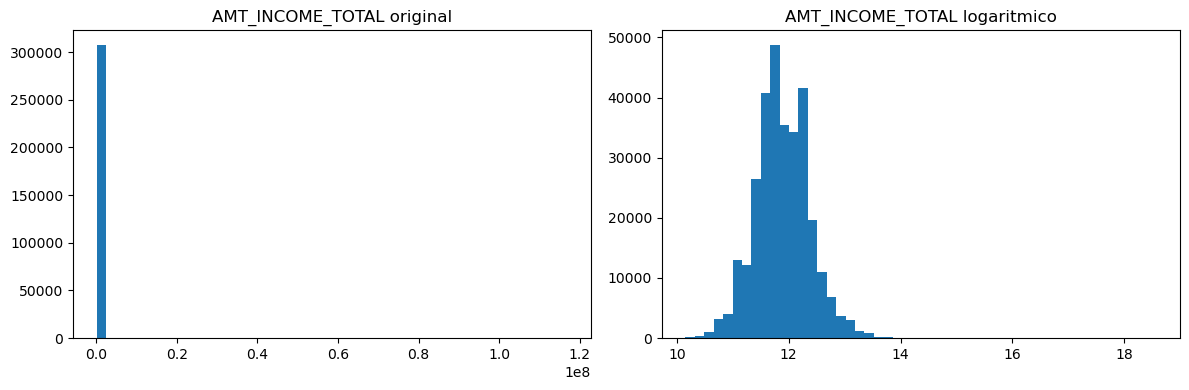

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(df['AMT_INCOME_TOTAL'], bins=50)
axes[0].set_title('AMT_INCOME_TOTAL original')

axes[1].hist(df['AMT_INCOME_TOTAL_LOG'], bins=50)
axes[1].set_title('AMT_INCOME_TOTAL logaritmico')

plt.tight_layout()
plt.show()

In [48]:
cols_nulos_num = df.select_dtypes(include='number').columns[df.select_dtypes(include='number').isnull().any().tolist()]
print(f"Columnas numéricas con nulos: {len(cols_nulos_num)}")
print(cols_nulos_num)

Columnas numéricas con nulos: 62
Index(['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED', 'OWN_CAR_AGE',
       'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
       'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
       'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG',
       'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG',
       'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE',
       'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE',
       'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI',
       'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
       'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI',
    

In [54]:
'''
La estrategia para tratar las columnas con nulos es:
- Para columnas con más de 40% de valores nulos creación de varaible binaria + imputación con mediana
- Para columnas con menos de 40% de nulos imputació directa con mediana
'''

for col in cols_nulos_num:
    pct_nulls = df[col].isnull().mean()
    
    if pct_nulls > 0.4:
        # Crear variable binaria
        df[f'{col}_was_null'] = df[col].isnull()
        
    # Imputar con mediana
    df[col] = df[col].fillna(df[col].median()) 

In [59]:
# Verificación de existencia de nulos luego de la imputación
df[cols_nulos_num].isnull().sum().sum()

np.int64(0)

In [63]:
# Columnas categoricas con nulos
cols_nulos_cat = df.select_dtypes(include='str').columns[df.select_dtypes(include='str').isnull().any().tolist()]
print(f'Cantidad de columnas categoricas con nulos: {len(cols_nulos_cat)}')
print(cols_nulos_cat)

Cantidad de columnas categoricas con nulos: 6
Index(['NAME_TYPE_SUITE', 'OCCUPATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')


In [69]:
for col in cols_nulos_cat:
    pct_nulls = (df[col].isnull().mean() * 100).round(2)
    moda = df[col].mode()[0]
    print(f'{col}: {pct_nulls}% nulos | moda: {moda}\n')

NAME_TYPE_SUITE: 0.42% nulos | moda: Unaccompanied

OCCUPATION_TYPE: 31.35% nulos | moda: Laborers

FONDKAPREMONT_MODE: 68.39% nulos | moda: reg oper account

HOUSETYPE_MODE: 50.18% nulos | moda: block of flats

WALLSMATERIAL_MODE: 50.84% nulos | moda: Panel

EMERGENCYSTATE_MODE: 47.4% nulos | moda: No



In [77]:
'''
Para las variables categoricas seguiremos la misma estrategia que con las numéricas, esta vez imputando con la moda en lugar de la mediana
'''
for col in cols_nulos_cat:
    pct_nulls = df[col].isnull().mean()
    
    if pct_nulls > 0.4:
        # Variable binaria
        df[col+'_was_null'] = df[col].isnull()
        
    # imputación con moda
    df[col] = df[col].fillna(df[col].mode()[0])

In [78]:
print('Shape original: (307511,122)')
print(f'Shape actual: {df.shape}')
print(f'Nulos totales: {df.isnull().sum().sum()}')

Shape original: (307511,122)
Shape actual: (307511, 174)
Nulos totales: 0


# Feature Engineering

In [79]:
# Creación de variable con sentido de negocio
df['ratio_deuda_ingreso'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ratio_anuidad_ingreso'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['ratio_antiguedad_empleo'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
df['docs_entregados'] = df[[c for c in df.columns if 'FLAG_DOCUMENT' in c]].sum(axis=1)

/tmp/ipykernel_1810/321706201.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ratio_deuda_ingreso'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
/tmp/ipykernel_1810/321706201.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ratio_anuidad_ingreso'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
/tmp/ipykernel_1810/321706201.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

In [80]:
new_vars = ['ratio_deuda_ingreso', 'ratio_anuidad_ingreso', 'ratio_antiguedad_empleo', 'docs_entregados']

df[new_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
ratio_deuda_ingreso,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,84.736842
ratio_anuidad_ingreso,307511.0,0.180929,0.094573,0.000224,0.114782,0.162833,0.229067,1.875965
ratio_antiguedad_empleo,307511.0,0.148516,0.122370,-0.000000,0.068385,0.110928,0.191527,0.728811
docs_entregados,307511.0,0.930155,0.344295,0.000000,1.000000,1.000000,1.000000,4.000000


In [ ]:
df['ratio_credito_valor'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

df[['ratio_credito_valor','AGE_YEARS']].describe()

,ratio_credito_valor,AGE_YEARS
count,307511.000000,307511.000000
mean,1.122449,43.938646
std,0.125755,11.964047
min,0.150000,21.000000
25%,1.000000,34.000000
50%,1.118800,43.000000
75%,1.198000,54.000000
max,6.000000,69.000000


In [89]:
# analisis de ratio credito-valor
print((df['ratio_credito_valor'] > 2).sum())
print((df['ratio_credito_valor'] > 2).mean() * 100)

26
0.008454982098201365


In [90]:
# Para que no genere ruido en el modelo, se limitará los valores extremos de ratio credito-valor a 2
df['ratio_credito_valor'] = df['ratio_credito_valor'].clip(upper=2)

In [91]:
df['ratio_credito_valor'].max()

np.float64(2.0)